<div dir="rtl" align="right">

# سوال 1 از آزمون فرض
</div>


In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro
from scipy.stats import mannwhitneyu

In [ ]:
# main data & labeled data for city classification
df = pd.read_csv("../../data/Divar.csv")
cities = pd.read_csv("../../data/iran_city_classification.csv")

cities.head()

C:\Users\loki\AppData\Local\Temp\ipykernel_16320\1019636771.py:1: DtypeWarning: Columns (0: rent_to_single, 1: floor, 2: total_floors_count, 3: extra_person_capacity) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../../data/Divar.csv")


,نام شهر,دسته‌بندی
0,karaj,کلان‌شهر
1,tehran,کلان‌شهر
2,mashhad,کلان‌شهر
3,ahvaz,کلان‌شهر
4,kermanshah,کلان‌شهر


In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 61 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   Unnamed: 0                  1000000 non-null  int64  
 1   cat2_slug                   1000000 non-null  str    
 2   cat3_slug                   999999 non-null   str    
 3   city_slug                   999998 non-null   str    
 4   neighborhood_slug           437139 non-null   str    
 5   created_at_month            1000000 non-null  str    
 6   user_type                   288882 non-null   str    
 7   description                 1000000 non-null  str    
 8   title                       999946 non-null   str    
 9   rent_mode                   352994 non-null   str    
 10  rent_value                  351322 non-null   float64
 11  rent_to_single              19 non-null       object 
 12  rent_type                   103961 non-null   str    
 13  price_mod

In [59]:
# map two data frames on city_slug
city_map = dict(zip(cities["نام شهر"], cities["دسته‌بندی"]))
df["city_type"] = df["city_slug"].map(city_map)
df[["city_slug", "city_type"]].head()

,city_slug,city_type
0,karaj,کلان‌شهر
1,tehran,کلان‌شهر
2,tehran,کلان‌شهر
3,tehran,کلان‌شهر
4,mashhad,کلان‌شهر


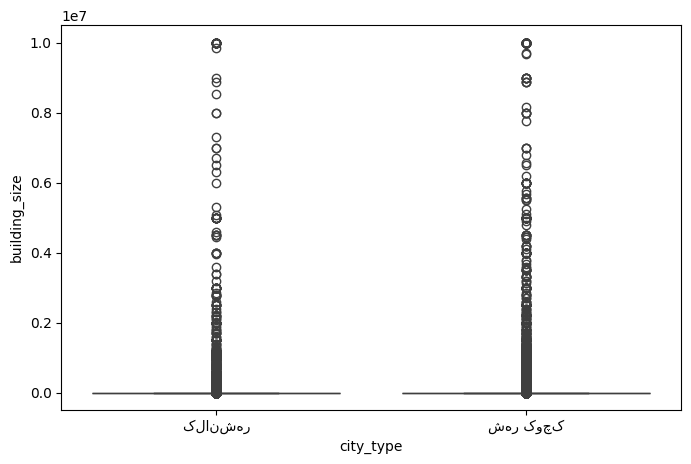

In [64]:
# handling the missing values of building_size & city_type and outliers
analysis_df = df.dropna(subset=["building_size", "city_type"])
plt.figure(figsize=(8,5))

sns.boxplot(
    data=analysis_df,
    x="city_type",
    y="building_size"
)

plt.show()

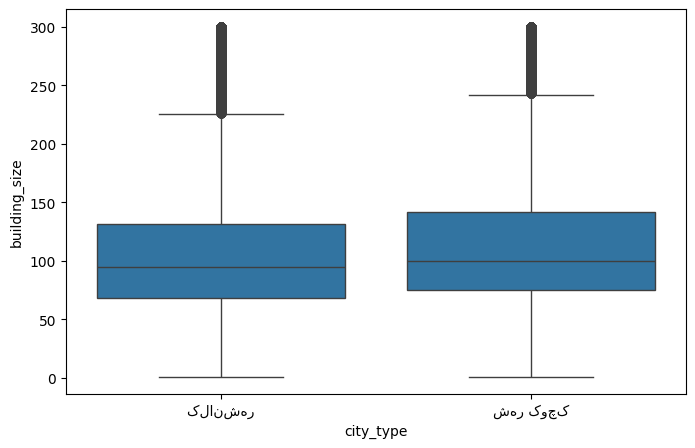

In [92]:
# data after deleting the outliers
Q1 = df['building_size'].quantile(0.25)
Q3 = df['building_size'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
cleand_df = analysis_df[(analysis_df['building_size'] >= lower_bound) & (analysis_df['building_size'] <= upper_bound)]

plt.figure(figsize=(8,5))

sns.boxplot(
    data=cleand_df,
    x="city_type",
    y="building_size"
)

plt.show()

In [67]:
# Checking for clean data normality with shapiro
big_cities = cleand_df[cleand_df["city_type"] == "کلان‌شهر"]["building_size"]
small_cities = cleand_df[cleand_df["city_type"] == "شهر کوچک"]["building_size"]

stat1, p1 = shapiro(big_cities)
stat2, p2 = shapiro(small_cities)
print('big cities:', p1)
print('small cities:', p2)

big cities: 5.6573147524805816e-129
small cities: 1.6514991452247057e-133


e:\Ai-Bootcamp-projects\Shoelace_area\env\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 421254.
  res = hypotest_fun_out(*samples, **kwds)
e:\Ai-Bootcamp-projects\Shoelace_area\env\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 425075.
  res = hypotest_fun_out(*samples, **kwds)


In [66]:
# Checking for data normality with shapiro
big_cities = analysis_df[analysis_df["city_type"] == "کلان‌شهر"]["building_size"]
small_cities = analysis_df[analysis_df["city_type"] == "شهر کوچک"]["building_size"]

stat1, p1 = shapiro(big_cities)
stat2, p2 = shapiro(small_cities)
print('big cities:', p1)
print('small cities:', p2)

big cities: 1.534201620342014e-223
small cities: 8.808169178127446e-225


e:\Ai-Bootcamp-projects\Shoelace_area\env\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 455121.
  res = hypotest_fun_out(*samples, **kwds)
e:\Ai-Bootcamp-projects\Shoelace_area\env\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 488988.
  res = hypotest_fun_out(*samples, **kwds)


<div dir="rtl" align="right">
همینطور که قابل مشاهده است بعد از انجام تست Shapiro چه برروی دیتای اصلی و چه بر روی دیتایی که داده های پرت ان پاک شده اند باز هم دیتای ما نرمال نیست پس به همین دلیل از Mann-Whitney Test استفاده میکنیم

</div>


In [91]:
# H0: Distribution of big cities >= Distribution of small cities  
# H1: Distribution of big cities < Distribution of small cities

u_stat, u_p = mannwhitneyu(big_cities, small_cities, alternative='less')

print(f"U-statistic: {u_stat:,.0f}")
print(f"p-value: {u_p:.5e}")

U-statistic: 83,409,861,392
p-value: 0.00000e+00


<div dir="rtl" align="right">
با توجه به مقدار بسیار کوچک p-value، فرض صفر (H0​) رد می شود و فرض مقابل (H1​) تایید می شود.
این نتیجه نشان می‌دهد که توزیع متراژ ساختمان‌ها در کلان‌شهرها به‌طور معناداری پایین‌تر از شهرهای کوچک است.

</div>


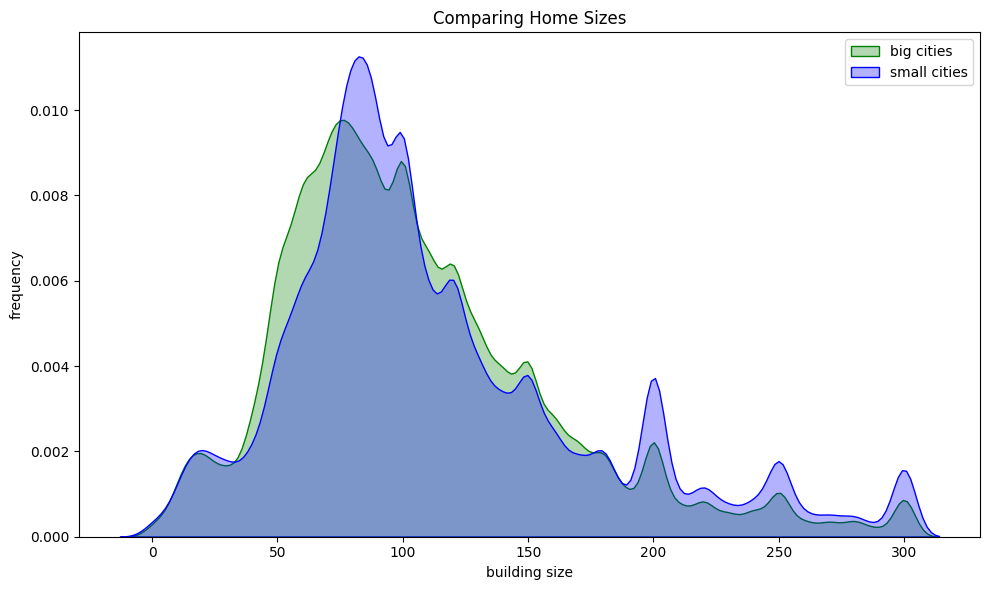

In [86]:
plt.figure(figsize=(10, 6))

sns.kdeplot(
    big_cities, 
    label='big cities', 
    fill=True, 
    color='green', 
    alpha=0.3
)
sns.kdeplot(
    small_cities, 
    label='small cities', 
    fill=True, 
    color='blue', 
    alpha=0.3
)

plt.title('Comparing Home Sizes')
plt.xlabel('building size')
plt.ylabel('frequency')
plt.legend()
plt.tight_layout()
plt.show()